In [6]:
import cupy as cp
import numpy as np

In [7]:
backward_solve_SDE = cp.ElementwiseKernel(
    'float32 k, float32 C',
    'float32 x_next',
    r'''
    const double pi = 3.141592653589793238462643383279502884;
    const double a  = 2.0 * pi;

    double kk = (double)k;
    double cc = (double)C;
    double x;

    if (fabs(kk) < 1.0e-100) {
        x = cc;
    } else {
        const double b = pi;   // drift center

        const double A = 1.0 + kk;
        const double B = -(cc + a + kk * (a + b));
        const double G = a * cc + a * b * kk - 2.0 * kk;
        const double D = a * kk;

        const double p = (3.0 * A * G - B * B) / (3.0 * A * A);
        const double q = (2.0 * B * B * B - 9.0 * A * B * G + 27.0 * A * A * D)
                       / (27.0 * A * A * A);

        const double Delta = 0.25 * q * q + (p * p * p) / 27.0;
        const double shift = -B / (3.0 * A);

        if (Delta >= 0.0) {
            const double s1 = rcbrt_double(-0.5 * q + sqrt(Delta));
            const double s2 = rcbrt_double(-0.5 * q - sqrt(Delta));
            x = s1 + s2 + shift;
        } else {
            const double rho = 2.0 * sqrt(-p / 3.0);
            double arg = (-0.5 * q) / sqrt(-((p / 3.0) * (p / 3.0) * (p / 3.0)));

            // important for numerical safety
            if (arg > 1.0) arg = 1.0;
            if (arg < -1.0) arg = -1.0;

            const double phi = acos(arg);

            const double r0 = rho * cos(phi / 3.0) + shift;
            const double r1 = rho * cos((phi + 2.0 * pi) / 3.0) + shift;
            const double r2 = rho * cos((phi + 4.0 * pi) / 3.0) + shift;

            double best = 0.0;
            double fbest = 0.0;
            bool found = false;

            if (r0 > 0.0 && r0 < a) {
                double fr = fabs(Fval(r0, kk, cc, a, pi));
                best = r0;
                fbest = fr;
                found = true;
            }
            if (r1 > 0.0 && r1 < a) {
                double fr = fabs(Fval(r1, kk, cc, a, pi));
                if (!found || fr < fbest) {
                    best = r1;
                    fbest = fr;
                    found = true;
                }
            }
            if (r2 > 0.0 && r2 < a) {
                double fr = fabs(Fval(r2, kk, cc, a, pi));
                if (!found || fr < fbest) {
                    best = r2;
                    fbest = fr;
                    found = true;
                }
            }

            if (found) {
                x = best;
            } else {
                x = nan("");
            }
        }
    }

    x_next = (float)x;
    ''',
    'backward_solve_SDE',
    preamble=r'''
    __device__ inline double rcbrt_double(double z) {
        return (z >= 0.0) ? cbrt(z) : -cbrt(-z);
    }

    __device__ inline double Fval(double x, double k, double C, double a, double pi) {
        return x - C - k * (pi - x + 1.0 / x + 1.0 / (x - a));
    }
    '''
)

In [8]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

# -------------------------------------------------
# Define your drift pieces on GPU
# -------------------------------------------------
def f(r):
    return cp.pi - r

def wall_rep(r):
    return 1.0 / r + 1.0 / (r - 2.0 * cp.pi)


# -------------------------------------------------
# Simulate one batch on GPU without storing the last values of all paths as indication of statioanry values
# -------------------------------------------------
def stationary_samples(n_paths, n_steps, T=10000.0, mu=1, epsilon=1, dtype=cp.float32):
    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)
    sqrt_epsilon = np.sqrt(epsilon)
    k = 2.0 * mu * dt
    x_ST = cp.full(n_paths, cp.pi, dtype=dtype)
    x_CST = cp.full(n_paths, cp.pi, dtype=dtype)
    x_IM = cp.full(n_paths, cp.pi, dtype=dtype)

    for step in range(n_steps):
        
        noise_term = 2*sqrt_epsilon*sqrt_dt * cp.random.randn(n_paths, dtype=dtype)
        
        C = x_IM+noise_term

        x_IM = backward_solve_SDE(k, C)

        x_ST = x_ST + 2.0 * mu * (f(x_ST) + wall_rep(x_ST)) * dt + noise_term
        x_CST = cp.clip(x_CST + 2.0 * mu * (f(x_CST) + wall_rep(x_CST)) * dt + noise_term, 1e-30, 2.0 * cp.pi-1e-30)
        

    return (
           x_IM,
           x_ST,
           x_CST
    )


In [15]:
n_paths = 10**6
n_steps = 10**4
T = 500.0
mu = 0.01
epsilon = 0.01
nbr_moments = 4

x_IM, x_ST, x_CST = stationary_samples(
    n_paths=n_paths,
    n_steps=n_steps,
    T=T,
    mu=mu,
    epsilon=epsilon,
    dtype=cp.float32
)


In [13]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt


# -------------------------------------------------
# Exact stationary density
# rho(x) \propto x^{mu/epsilon} (2pi-x)^{mu/epsilon}
#            exp(-(mu/(2epsilon))(x-pi)^2),   x in (0,2pi)
# -------------------------------------------------
def _log_stationary_unnormalized(x, mu, epsilon):
    x = np.asarray(x, dtype=np.float64)
    return (
        (mu / epsilon) * (np.log(x) + np.log(2.0 * np.pi - x))
        - (mu / (2.0 * epsilon)) * (x - np.pi) ** 2
    )


def exact_stationary_density_grid(mu, epsilon, n_grid=5000, delta=1e-8):
    x_grid = np.linspace(delta, 2.0 * np.pi - delta, n_grid)
    log_rho = _log_stationary_unnormalized(x_grid, mu, epsilon)
    log_rho -= np.max(log_rho)   # numerical stabilization
    rho = np.exp(log_rho)
    Z = np.trapz(rho, x_grid)
    rho /= Z
    return x_grid, rho


# -------------------------------------------------
# KL divergence between empirical histogram and exact density
# -------------------------------------------------
def empirical_vs_exact_kl(samples_np, mu, epsilon, n_bins=150, delta=1e-8):
    samples_np = np.asarray(samples_np, dtype=np.float64)
    samples_np = samples_np[np.isfinite(samples_np)]

    # keep only values in the physical interval
    valid = samples_np[(samples_np > 0.0) & (samples_np < 2.0 * np.pi)]

    if valid.size == 0:
        return np.inf, valid, None, None, None

    bins = np.linspace(delta, 2.0 * np.pi - delta, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    bin_widths = np.diff(bins)

    # empirical histogram as a discrete pmf
    counts, _ = np.histogram(valid, bins=bins)
    p = counts.astype(np.float64)
    p /= p.sum()

    # exact distribution turned into bin masses
    log_q = _log_stationary_unnormalized(centers, mu, epsilon)
    log_q -= np.max(log_q)
    q = np.exp(log_q) * bin_widths
    q /= q.sum()

    # KL(p || q)
    mask = p > 0.0
    kl = np.sum(p[mask] * np.log(p[mask] / q[mask]))

    return kl, valid, bins, p, q


# -------------------------------------------------
# Single plotting helper
# -------------------------------------------------
def _plot_one_stationary_distribution(samples, name, mu, epsilon, n_bins=150, delta=1e-8):
    if isinstance(samples, cp.ndarray):
        samples_np = cp.asnumpy(samples)
    else:
        samples_np = np.asarray(samples)

    kl, valid, bins, p, q = empirical_vs_exact_kl(
        samples_np, mu=mu, epsilon=epsilon, n_bins=n_bins, delta=delta
    )

    x_grid, rho_grid = exact_stationary_density_grid(mu, epsilon, delta=delta)

    plt.figure(figsize=(9, 5))
    
    if valid.size > 0:
        plt.hist(
            valid,
            bins=bins,
            density=True,
            alpha=0.6,
            label="Empirical histogram"
        )

    plt.plot(
        x_grid,
        rho_grid,
        linewidth=2.5,
        label="Exact stationary density"
    )

    plt.axvline(np.pi, linestyle="--", linewidth=1.5, label=r"$x=\pi$")

    plt.xlim(0.0, 2.0 * np.pi)
    plt.xlabel(r"$x$")
    plt.ylabel("Density")
    plt.title(f"{name} stationary distribution")

    kept_fraction = valid.size / max(1, np.isfinite(samples_np).sum())
    text = (
        rf"$D_{{KL}}(\hat p\|p_\infty) = {kl:.6f}$" + "\n" +
        rf"valid samples in $(0,2\pi)$: {valid.size}/{np.isfinite(samples_np).sum()}" + "\n" +
        rf"kept fraction: {kept_fraction:.4f}"
    )

    plt.text(
        0.02, 0.98, text,
        transform=plt.gca().transAxes,
        ha="left", va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
    )

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return kl


# -------------------------------------------------
# Main function: creates three separate plots
# -------------------------------------------------
def plot_three_stationary_distributions(x_IM, x_ST, x_CST, mu, epsilon, n_bins=150, delta=1e-8):
    kl_backward = _plot_one_stationary_distribution(
        x_IM, "Backward Euler", mu=mu, epsilon=epsilon, n_bins=n_bins, delta=delta
    )

    kl_standard = _plot_one_stationary_distribution(
        x_ST, "Standard Euler", mu=mu, epsilon=epsilon, n_bins=n_bins, delta=delta
    )

    kl_clipped = _plot_one_stationary_distribution(
        x_CST, "Clipped Euler", mu=mu, epsilon=epsilon, n_bins=n_bins, delta=delta
    )

    print("KL divergences")
    print(f"Backward Euler : {kl_backward:.6f}")
    print(f"Standard Euler : {kl_standard:.6f}")
    print(f"Clipped Euler  : {kl_clipped:.6f}")

    return {
        "Backward Euler": kl_backward,
        "Standard Euler": kl_standard,
        "Clipped Euler": kl_clipped,
    }

C:\Users\johan\AppData\Local\Temp\ipykernel_31764\4015247638.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z = np.trapz(rho, x_grid)


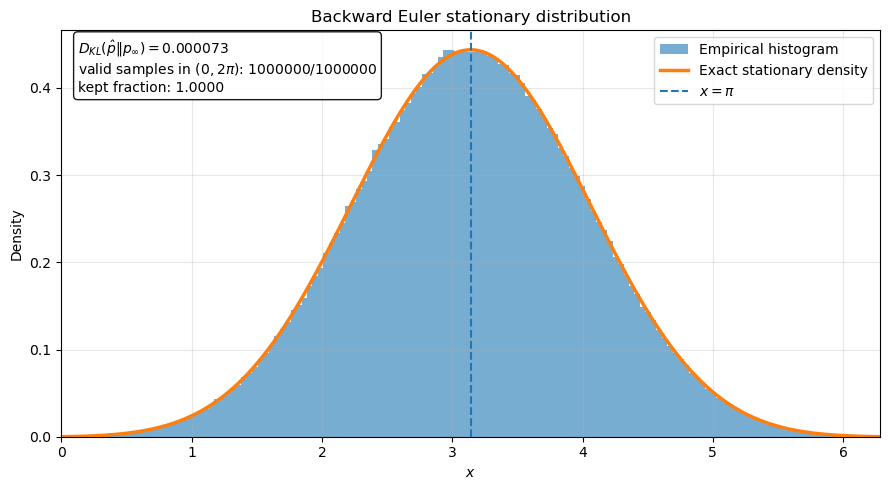

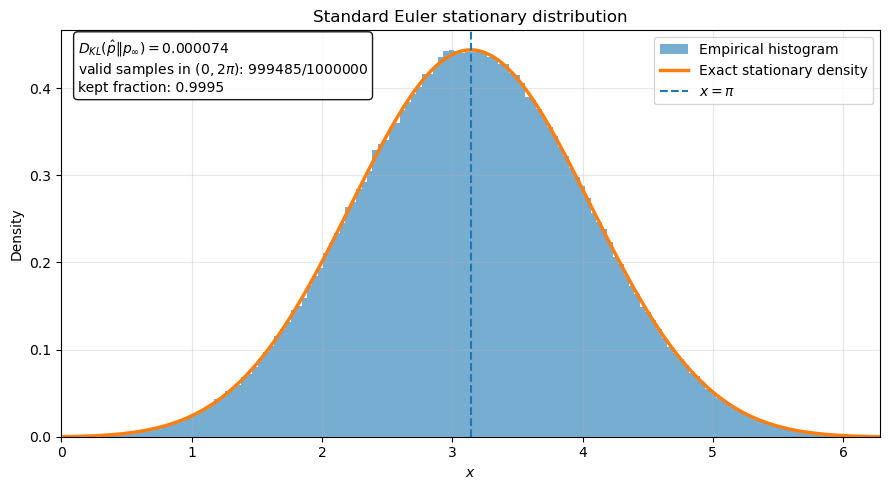

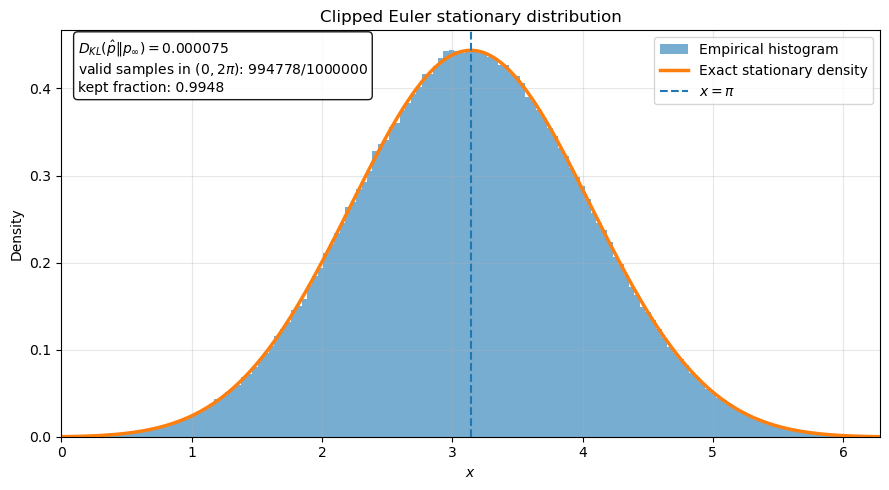

KL divergences
Backward Euler : 0.000073
Standard Euler : 0.000074
Clipped Euler  : 0.000075


In [16]:
kl_results = plot_three_stationary_distributions(
    x_IM=x_IM,
    x_ST=x_ST,
    x_CST=x_CST,
    mu=mu,
    epsilon=epsilon,
    n_bins=150
)